In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import MESA_DATA_DIR, DATA_DIR

In [3]:
plt.style.use('plotstyle.mplstyle')

In [4]:
def get_model_folder(model_id, verbose=True):
    """Finds model folder given its id."""
    matches = list(PROJECT_FOLDER.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {PROJECT_FOLDER}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {PROJECT_FOLDER}')
        return           
    
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        m, p, w = model_folder.name.replace('d', 'e').split('_')
        w = float(w.lstrip('w'))
        p = f'{float(p.lstrip("p")):.2f}'      
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [5]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

# Each entry: { label used in all_model_dicts : (variable suffix, folder name) }
metallicity_map = {
  #  '0.0005': ('0005zsun', '0000_ZdivZsun_5d-03'),
  #  '0.001':  ('001zsun',  '0001_ZdivZsun_1d-02'),
    '0.02':  ('002zsun',  '0002_ZdivZsun_2d-02'),
    '0.04':  ('004zsun',  '0003_ZdivZsun_4d-02'),
    '0.08':  ('008zsun',  '0004_ZdivZsun_8d-02'),
    '0.1':   ('01zsun',   '0005_ZdivZsun_1d-01'),
    '0.2':   ('02zsun',   '0006_ZdivZsun_2d-01'),
    '0.3':   ('03zsun',   '0007_ZdivZsun_3d-01'),
    '0.4':   ('04zsun',   '0008_ZdivZsun_4d-01'),
}

# initialize container for final dict
all_model_dicts = {}

for z_label, (suffix, folder_name) in metallicity_map.items():
    PROJECT_FOLDER = PROJECT_BASE / folder_name

    model_ids = np.arange(1, 25, 1)
    model_ids = np.array([f'{id:03d}' for id in model_ids])
    model_folders = np.array([get_model_folder(id) for id in model_ids])
    model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_labels = np.array([f'${float(id):0f}\\,\\mathrm{{M}}_\\odot$' for id in model_ids])

    # create a variable named model_dicts_XXXzsun dynamically
    globals()[f'model_dicts_{suffix}'] = model_dicts

    # add entry to final dict (same structure as before)
    all_model_dicts[z_label] = {
    k: v
    for d in model_dicts
    for k, v in d.items()
}



Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/001_m10
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/002_m15
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/003_m20
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/004_m25
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/005_m30
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/006_m35
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/007_m40
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/008_m45
Found match /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZs

In [6]:
import pandas as pd
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')

In [7]:
suc_che_df = core_props_df[(~core_props_df.is_l2of_at_zams) & (core_props_df.is_che) & (~core_props_df.is_crash)]

In [8]:
suc_che_df['z'] = suc_che_df['z_key'].astype(float)

/tmp/ipykernel_3017299/2058798488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  suc_che_df['z'] = suc_che_df['z_key'].astype(float)


In [9]:
list(suc_che_df.columns)

['z_key',
 'm_zams',
 'm_wr0',
 'm_wr1',
 'm_tams',
 'm_tahems',
 'm_cdepl',
 'm_odepl',
 'm_f',
 'm_hecore_zams',
 'm_hecore_wr0',
 'm_hecore_wr1',
 'm_hecore_tams',
 'm_hecore_tahems',
 'm_hecore_cdepl',
 'm_hecore_odepl',
 'm_hecore_f',
 'm_cocore_zams',
 'm_cocore_wr0',
 'm_cocore_wr1',
 'm_cocore_tams',
 'm_cocore_tahems',
 'm_cocore_cdepl',
 'm_cocore_odepl',
 'm_cocore_f',
 'inertia_zams',
 'inertia_wr0',
 'inertia_wr1',
 'inertia_tams',
 'inertia_tahems',
 'inertia_cdepl',
 'inertia_odepl',
 'inertia_f',
 'p_spin_zams',
 'p_spin_wr0',
 'p_spin_wr1',
 'p_spin_tams',
 'p_spin_tahems',
 'p_spin_cdepl',
 'p_spin_odepl',
 'p_spin_f',
 'r_zams',
 'r_wr0',
 'r_wr1',
 'r_tams',
 'r_tahems',
 'r_cdepl',
 'r_odepl',
 'r_f',
 'r_hecore_zams',
 'r_hecore_wr0',
 'r_hecore_wr1',
 'r_hecore_tams',
 'r_hecore_tahems',
 'r_hecore_cdepl',
 'r_hecore_odepl',
 'r_hecore_f',
 'r_cocore_zams',
 'r_cocore_wr0',
 'r_cocore_wr1',
 'r_cocore_tams',
 'r_cocore_tahems',
 'r_cocore_cdepl',
 'r_cocore_odepl

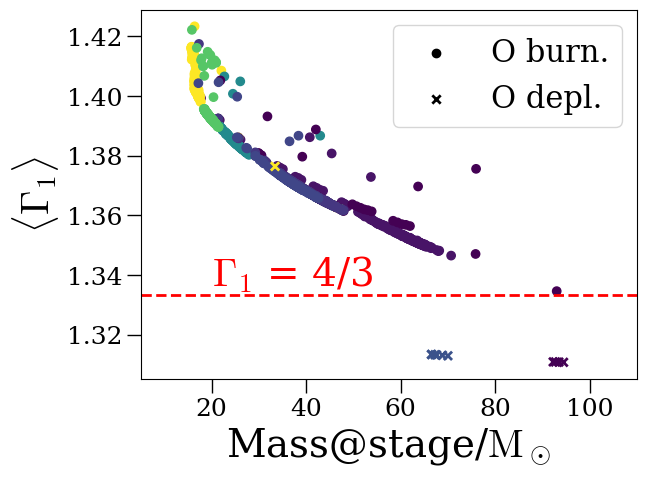

In [10]:
fig, ax = plt.subplots()

df = suc_che_df[~suc_che_df.is_O_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z
)



ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right')

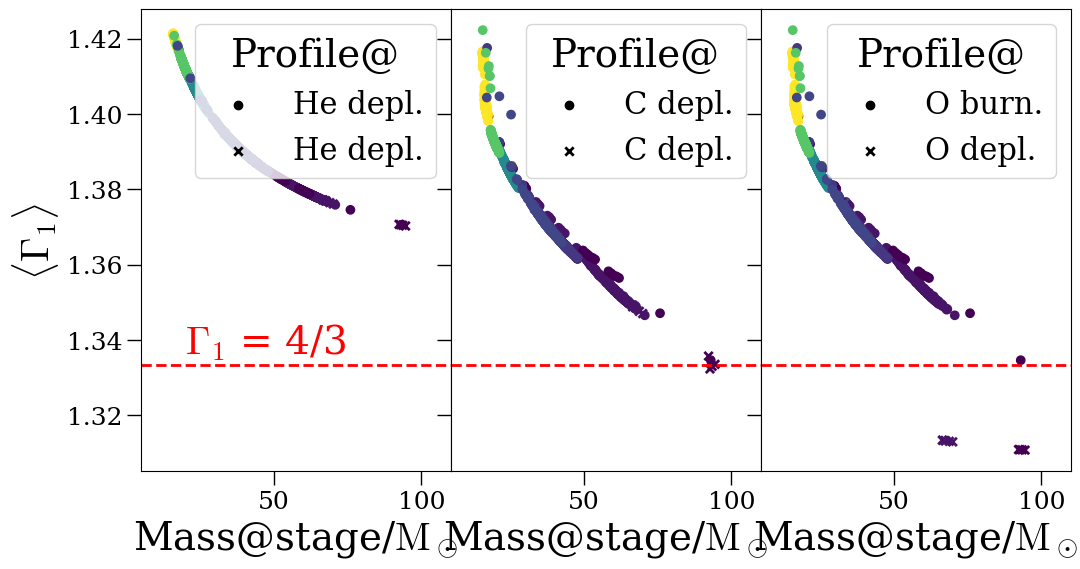

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
fig.subplots_adjust(wspace=0)


ax = axes[0]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='He depl.'),
    ax.scatter([], [], marker='x', color='k', label='He depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')


ax = axes[1]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')


ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='C depl.'),
    ax.scatter([], [], marker='x', color='k', label='C depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

ax = axes[2]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
#ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

In [12]:
suc_che_df.columns

Index(['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_cdepl',
       'm_odepl', 'm_f', 'm_hecore_zams',
       ...
       'is_che', 'is_crit_at_zams', 'is_merger_at_zams', 'is_l2of_at_zams',
       'is_He_depleted', 'is_half_C_depleted', 'is_C_depleted',
       'is_O_depleted', 'is_crash', 'z'],
      dtype='object', length=172)

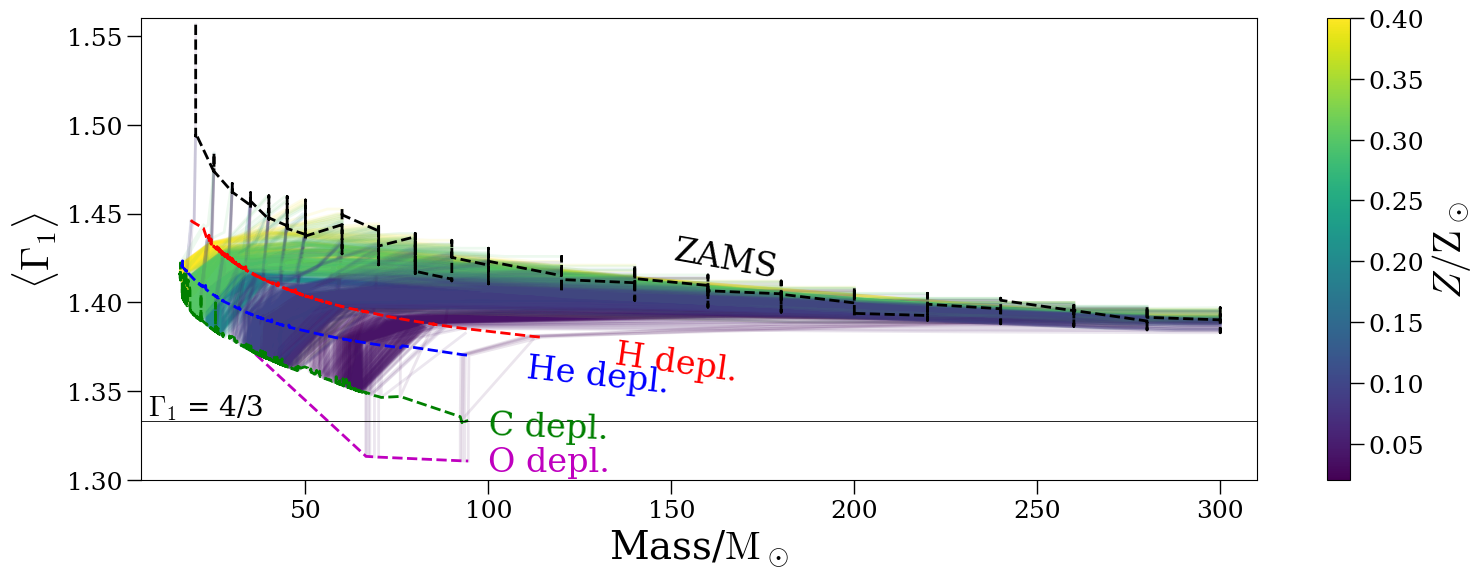

In [13]:
stages = ['zams', 'wr0', 'wr1', 'tams', 'tahems', 'cdepl', 'odepl']

fig, ax = plt.subplots(figsize=(18, 6))

for row in suc_che_df.itertuples():
    m = [getattr(row, 'm_'+stage) for stage in stages]
    z = row.z
    gamma1_w_avg_values = [getattr(row, f'gamma1_w_avg_{stage}') for stage in stages]
    ax.plot(
        m,
        gamma1_w_avg_values,
        marker='none',
        color=plt.cm.viridis((z-0.02)/0.38),
        alpha=0.1
    )
    
all_odepl_df = suc_che_df[suc_che_df.is_O_depleted]
odepl_x = [getattr(row, 'm_odepl') for row in all_odepl_df.itertuples()]
odepl_y = [getattr(row, 'gamma1_w_avg_odepl') for row in all_odepl_df.itertuples()]
sorted_indices = np.argsort(odepl_x)
ax.plot(
    np.array(odepl_x)[sorted_indices],
    np.array(odepl_y)[sorted_indices],
    marker='none',
    color='m',
    linestyle='--',
    label='O depl.'
)

all_cdepl_df = suc_che_df[suc_che_df.is_C_depleted]
cdepl_x = [getattr(row, 'm_cdepl') for row in all_cdepl_df.itertuples()]
cdepl_y = [getattr(row, 'gamma1_w_avg_cdepl') for row in all_cdepl_df.itertuples()]
sorted_indices = np.argsort(cdepl_x)
ax.plot(
    np.array(cdepl_x)[sorted_indices],
    np.array(cdepl_y)[sorted_indices],
    marker='none',
    color='g',
    linestyle='--',
    label='C depl.'
)

all_hedepl_df = suc_che_df[suc_che_df.is_He_depleted]
hedepl_x = [getattr(row, 'm_tahems') for row in all_hedepl_df.itertuples()]
hedepl_y = [getattr(row, 'gamma1_w_avg_tahems') for row in all_hedepl_df.itertuples()]
sorted_indices = np.argsort(hedepl_x)
ax.plot(
    np.array(hedepl_x)[sorted_indices],
    np.array(hedepl_y)[sorted_indices],
    marker='none',
    color='b',
    linestyle='--',
    label='He depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_tams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_tams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='r',
    linestyle='--',
    label='H depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_zams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_zams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='k',
    linestyle='--',
    label='ZAMS'
)


###



###

ax.hlines(4/3, 5, 310, colors='k', lw=0.6, linestyles='-')
ax.text(7, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='k', fontsize=20)
ax.set_xlim(5, 310)
ax.set_ylim(1.3, 1.56)
ax.set_xlabel('Mass/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')
#ax.set_title('Mass X $\\langle\Gamma_1\\rangle$ over time for all CHE models')

ax.text(150, 1.41, 'ZAMS', color='k', rotation=-10, va='bottom', ha='left', fontsize=24)
ax.text(134, 1.38, 'H depl.', color='r', rotation=-8, va='top', ha='left', fontsize=24)
ax.text(110, 1.372, 'He depl.', color='b', rotation=-6, va='top', ha='left', fontsize=24)
ax.text(100, 1.33, 'C depl.', color='g', rotation=-2, va='center', ha='left', fontsize=24)
ax.text(100, 1.31, 'O depl.', color='m', rotation=0, va='center', ha='left', fontsize=24)

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0.02, vmax=0.4)), ax=ax)
cbar.set_label('$Z/\\mathrm{Z}_\\odot$')

All models that develop global PI by C depl undergo PISNe.

In [14]:
suc_che_df[(suc_che_df.is_C_depleted) & (suc_che_df.gamma1_w_avg_cdepl < 4/3) ].gamma1_center_cdepl.max() < 4/3

np.True_

All models that develop global PI by O depl undergo PPISNe.

In [15]:
suc_che_df[(suc_che_df.is_O_depleted) & (suc_che_df.gamma1_w_avg_cdepl > 4/3) & (suc_che_df.gamma1_w_avg_odepl < 4/3)].gamma1_center_odepl.min() > 4/3

np.True_

In [16]:
pd.options.display.max_columns = None

In [17]:
suc_che_df[(suc_che_df.z == 0.4) & (suc_che_df.m_cdepl > 20)]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_hecore_zams,m_hecore_wr0,m_hecore_wr1,m_hecore_tams,m_hecore_tahems,m_hecore_cdepl,m_hecore_odepl,m_hecore_f,m_cocore_zams,m_cocore_wr0,m_cocore_wr1,m_cocore_tams,m_cocore_tahems,m_cocore_cdepl,m_cocore_odepl,m_cocore_f,inertia_zams,inertia_wr0,inertia_wr1,inertia_tams,inertia_tahems,inertia_cdepl,inertia_odepl,inertia_f,p_spin_zams,p_spin_wr0,p_spin_wr1,p_spin_tams,p_spin_tahems,p_spin_cdepl,p_spin_odepl,p_spin_f,r_zams,r_wr0,r_wr1,r_tams,r_tahems,r_cdepl,r_odepl,r_f,r_hecore_zams,r_hecore_wr0,r_hecore_wr1,r_hecore_tams,r_hecore_tahems,r_hecore_cdepl,r_hecore_odepl,r_hecore_f,r_cocore_zams,r_cocore_wr0,r_cocore_wr1,r_cocore_tams,r_cocore_tahems,r_cocore_cdepl,r_cocore_odepl,r_cocore_f,log_rho_hecore_zams,log_rho_hecore_wr0,log_rho_hecore_wr1,log_rho_hecore_tams,log_rho_hecore_tahems,log_rho_hecore_cdepl,log_rho_hecore_odepl,log_rho_hecore_f,log_rho_cocore_zams,log_rho_cocore_wr0,log_rho_cocore_wr1,log_rho_cocore_tams,log_rho_cocore_tahems,log_rho_cocore_cdepl,log_rho_cocore_odepl,log_rho_cocore_f,log_j_zams,log_j_wr0,log_j_wr1,log_j_tams,log_j_tahems,log_j_cdepl,log_j_odepl,log_j_f,log_j_hecore_zams,log_j_hecore_wr0,log_j_hecore_wr1,log_j_hecore_tams,log_j_hecore_tahems,log_j_hecore_cdepl,log_j_hecore_odepl,log_j_hecore_f,log_j_cocore_zams,log_j_cocore_wr0,log_j_cocore_wr1,log_j_cocore_tams,log_j_cocore_tahems,log_j_cocore_cdepl,log_j_cocore_odepl,log_j_cocore_f,chi_zams,chi_wr0,chi_wr1,chi_tams,chi_tahems,chi_cdepl,chi_odepl,chi_f,chi_hecore_zams,chi_hecore_wr0,chi_hecore_wr1,chi_hecore_tams,chi_hecore_tahems,chi_hecore_cdepl,chi_hecore_odepl,chi_hecore_f,chi_cocore_zams,chi_cocore_wr0,chi_cocore_wr1,chi_cocore_tams,chi_cocore_tahems,chi_cocore_cdepl,chi_cocore_odepl,chi_cocore_f,p_orb_zams,p_orb_wr0,p_orb_wr1,p_orb_tams,p_orb_tahems,p_orb_cdepl,p_orb_odepl,p_orb_f,log_t_d,temperature_center_zams,temperature_center_wr0,temperature_center_wr1,temperature_center_tams,temperature_center_tahems,temperature_center_cdepl,temperature_center_odepl,temperature_center_f,gamma1_center_zams,gamma1_center_wr0,gamma1_center_wr1,gamma1_center_tams,gamma1_center_tahems,gamma1_center_cdepl,gamma1_center_odepl,gamma1_center_f,gamma1_w_avg_zams,gamma1_w_avg_wr0,gamma1_w_avg_wr1,gamma1_w_avg_tams,gamma1_w_avg_tahems,gamma1_w_avg_cdepl,gamma1_w_avg_odepl,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
1260,0.4000,160.0,159.283906,95.441874,52.951214,41.265890,41.186157,53.073417,41.186157,0.0,0.0,0.0,52.951522,41.269291,41.186157,52.976292,41.186157,0.0,0.0,0.0,0.0,38.286695,38.286695,0.0,38.286695,3.998356e+58,3.998356e+58,1.011864e+58,1.410072e+57,9.364785e+55,7.169116e+54,1.898406e+57,7.169116e+54,2.0,2.249238,21.981067,17.088981,2.770403,0.504698,27.834980,0.442959,14.998329,14.998329,10.673117,5.122267,1.835851,0.710930,5.887840,0.710930,0.0,0.0,0.0,5.122267,1.835851,0.710930,5.887840,0.710930,0.0,0.0,0.0,0.0,0.752509,0.220072,0.0,0.220072,NaN,NaN,NaN,-8.827293,-8.568334,-7.579517,-8.898054,-7.579517,NaN,NaN,NaN,NaN,1.263121,2.748940,NaN,2.748940,53.727055,53.727055,52.650465,52.214271,51.917465,51.914948,52.214749,51.914948,NaN,NaN,NaN,52.214271,51.917465,51.914948,52.214749,51.914948,NaN,NaN,NaN,NaN,51.831774,51.831575,NaN,51.831575,2.367107,2.388438,0.557686,0.663625,0.551678,0.550616,0.661299,0.550616,NaN,NaN,NaN,0.663617,0.551587,0.550616,0.663726,0.550616,NaN,NaN,NaN,NaN,0.526116,0.525874,NaN,0.525874,2.438659,2.438659,8.708473,18.164451,29.868155,29.994673,18.146091,29.994673,12.022780,5.268320e+07,5.268320e+07,5.521867e+07,1.043747e+08,3.256406e+08,1.364744e+09,8.986059e+07,1.364744e+09,1.401456,1.401456,1.402939,1.397334,1.384230,1.386844,1.397560,1.386844,1.406009,1.406009,1.407714,1.401722,1.388806,1.367213,1.401914,1.367213,True,False,False,False,True,True,True,False,False,0.4
1261,0.4000,160.0,138.278371,82.107753,51.208733,40.230575,40.157722,51.321380,40.157722,0.0,0.

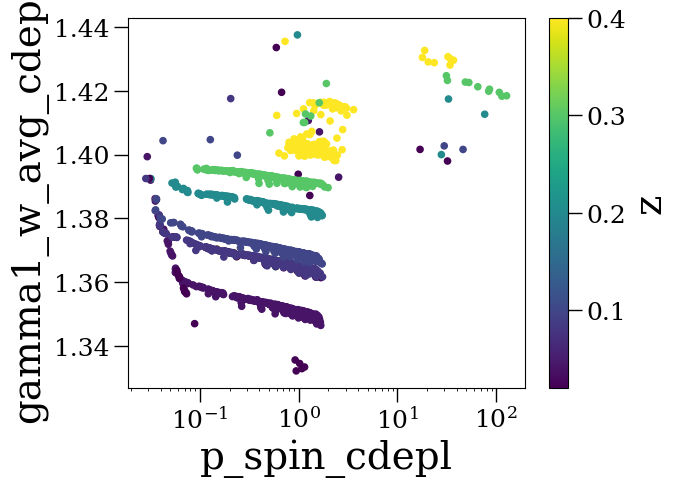

In [18]:
fig, ax = plt.subplots()
suc_che_df.plot.scatter(y='gamma1_w_avg_cdepl', x='p_spin_cdepl', c='z', ax=ax)
ax.set_xscale('log')

In [19]:
odepl_df = suc_che_df[suc_che_df.is_O_depleted].copy()

In [20]:
suc_che_df.z.unique()

array([0.04, 0.4 , 0.2 , 0.02, 0.08, 0.3 , 0.1 ])

In [21]:
odepl_df[odepl_df.z == 0.1]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_hecore_zams,m_hecore_wr0,m_hecore_wr1,m_hecore_tams,m_hecore_tahems,m_hecore_cdepl,m_hecore_odepl,m_hecore_f,m_cocore_zams,m_cocore_wr0,m_cocore_wr1,m_cocore_tams,m_cocore_tahems,m_cocore_cdepl,m_cocore_odepl,m_cocore_f,inertia_zams,inertia_wr0,inertia_wr1,inertia_tams,inertia_tahems,inertia_cdepl,inertia_odepl,inertia_f,p_spin_zams,p_spin_wr0,p_spin_wr1,p_spin_tams,p_spin_tahems,p_spin_cdepl,p_spin_odepl,p_spin_f,r_zams,r_wr0,r_wr1,r_tams,r_tahems,r_cdepl,r_odepl,r_f,r_hecore_zams,r_hecore_wr0,r_hecore_wr1,r_hecore_tams,r_hecore_tahems,r_hecore_cdepl,r_hecore_odepl,r_hecore_f,r_cocore_zams,r_cocore_wr0,r_cocore_wr1,r_cocore_tams,r_cocore_tahems,r_cocore_cdepl,r_cocore_odepl,r_cocore_f,log_rho_hecore_zams,log_rho_hecore_wr0,log_rho_hecore_wr1,log_rho_hecore_tams,log_rho_hecore_tahems,log_rho_hecore_cdepl,log_rho_hecore_odepl,log_rho_hecore_f,log_rho_cocore_zams,log_rho_cocore_wr0,log_rho_cocore_wr1,log_rho_cocore_tams,log_rho_cocore_tahems,log_rho_cocore_cdepl,log_rho_cocore_odepl,log_rho_cocore_f,log_j_zams,log_j_wr0,log_j_wr1,log_j_tams,log_j_tahems,log_j_cdepl,log_j_odepl,log_j_f,log_j_hecore_zams,log_j_hecore_wr0,log_j_hecore_wr1,log_j_hecore_tams,log_j_hecore_tahems,log_j_hecore_cdepl,log_j_hecore_odepl,log_j_hecore_f,log_j_cocore_zams,log_j_cocore_wr0,log_j_cocore_wr1,log_j_cocore_tams,log_j_cocore_tahems,log_j_cocore_cdepl,log_j_cocore_odepl,log_j_cocore_f,chi_zams,chi_wr0,chi_wr1,chi_tams,chi_tahems,chi_cdepl,chi_odepl,chi_f,chi_hecore_zams,chi_hecore_wr0,chi_hecore_wr1,chi_hecore_tams,chi_hecore_tahems,chi_hecore_cdepl,chi_hecore_odepl,chi_hecore_f,chi_cocore_zams,chi_cocore_wr0,chi_cocore_wr1,chi_cocore_tams,chi_cocore_tahems,chi_cocore_cdepl,chi_cocore_odepl,chi_cocore_f,p_orb_zams,p_orb_wr0,p_orb_wr1,p_orb_tams,p_orb_tahems,p_orb_cdepl,p_orb_odepl,p_orb_f,log_t_d,temperature_center_zams,temperature_center_wr0,temperature_center_wr1,temperature_center_tams,temperature_center_tahems,temperature_center_cdepl,temperature_center_odepl,temperature_center_f,gamma1_center_zams,gamma1_center_wr0,gamma1_center_wr1,gamma1_center_tams,gamma1_center_tahems,gamma1_center_cdepl,gamma1_center_odepl,gamma1_center_f,gamma1_w_avg_zams,gamma1_w_avg_wr0,gamma1_w_avg_wr1,gamma1_w_avg_tams,gamma1_w_avg_tahems,gamma1_w_avg_cdepl,gamma1_w_avg_odepl,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
6112,0.1000,80.0,79.291928,55.289169,43.487064,33.47627,33.417166,33.416511,33.416511,0.0,0.0,42.474668,42.500893,33.478399,33.417166,33.416511,33.416511,0.0,0.0,0.0,0.0,30.466943,30.466943,32.919917,32.919917,9.680053e+57,9.680053e+57,3.198870e+57,1.016146e+57,6.151019e+55,4.904620e+54,1.218336e+55,1.218336e+55,0.9,1.05299,13.47588,9.796051,0.858446,0.121711,0.186838,0.174399,10.471253,10.471253,9.072916,5.365848,1.602317,0.638747,1.059139,1.059139,0.0,0.0,4.148115,2.948659,1.602317,0.638747,1.059139,1.059139,0.0,0.0,0.0,0.0,0.648671,0.192046,0.477968,0.477968,NaN,NaN,-0.927853,-0.889184,-8.56326,-7.683452,-8.563155,-8.563155,NaN,NaN,NaN,NaN,1.427112,2.893866,1.177546,1.177546,53.395531,53.395531,52.496552,52.434645,52.06292,52.059465,52.059663,52.059663,NaN,NaN,52.42977,52.415134,52.06292,52.059465,52.059663,52.059663,NaN,NaN,NaN,NaN,51.950618,51.949169,52.026855,52.026855,4.413202,4.492373,1.165937,1.634286,1.171789,1.166618,1.167196,1.167196,NaN,NaN,1.694,1.635841,1.17164,1.166618,1.167196,1.167196,NaN,NaN,NaN,NaN,1.092354,1.088714,1.11517,1.11517,1.121059,1.121059,2.723158,3.03283,5.117348,5.136914,5.137114,5.137114,10.130198,4.996170e+07,4.996170e+07,5.926186e+07,1.008944e+08,3.216418e+08,1.327480e+09,2.489626e+09,2.489626e+09,1.422885,1.422885,1.406579,1.403678,1.389506,1.40122,1.387695,1.387695,1.430332,1.430332,1.411824,1.408738,1.394808,1.374842,1.376436,1.376436,True,False,False,False,True,True,True,True,False,0.1


Text(20, 1.3363333333333332, '$\\Gamma_1$ = 4/3')

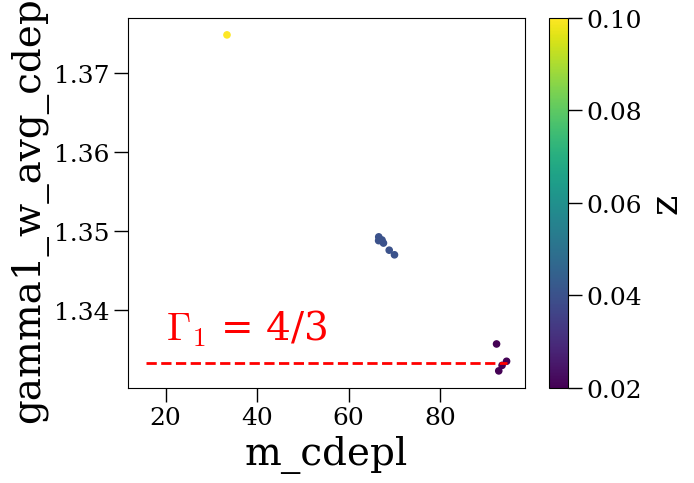

In [22]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_O_depleted)].plot.scatter(x='m_cdepl', y='gamma1_w_avg_cdepl', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_cdepl'].min(), xmax=suc_che_df['m_cdepl'].max(), colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

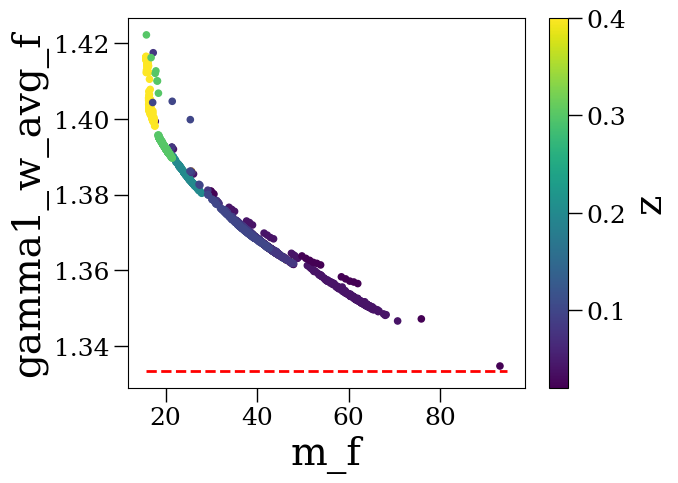

In [23]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_C_depleted) & (~suc_che_df.is_O_depleted)].plot.scatter(x='m_f', y='gamma1_w_avg_f', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_f'].min(), xmax=suc_che_df['m_f'].max(), colors='r', linestyles='dashed')

<Axes: xlabel='m_f', ylabel='z'>

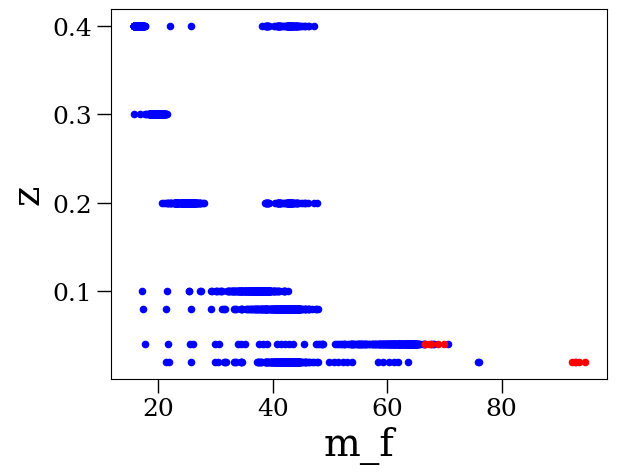

In [24]:
fig, ax = plt.subplots()
suc_che_df[suc_che_df.gamma1_w_avg_f > 4/3].plot.scatter(x='m_f', y='z', color='b', ax=ax)
suc_che_df[suc_che_df.gamma1_w_avg_f <= 4/3].plot.scatter(x='m_f', y='z', color='r', ax=ax)

## Core masses and PI threshold

Are our stars generally naked He cores? CO cores? What can we say, or implement from past work, in terms of the core threshold for PI?

In [25]:
pd.set_option('display.max_columns', None)

In [26]:
print(list(core_props_df.columns))

['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_cdepl', 'm_odepl', 'm_f', 'm_hecore_zams', 'm_hecore_wr0', 'm_hecore_wr1', 'm_hecore_tams', 'm_hecore_tahems', 'm_hecore_cdepl', 'm_hecore_odepl', 'm_hecore_f', 'm_cocore_zams', 'm_cocore_wr0', 'm_cocore_wr1', 'm_cocore_tams', 'm_cocore_tahems', 'm_cocore_cdepl', 'm_cocore_odepl', 'm_cocore_f', 'inertia_zams', 'inertia_wr0', 'inertia_wr1', 'inertia_tams', 'inertia_tahems', 'inertia_cdepl', 'inertia_odepl', 'inertia_f', 'p_spin_zams', 'p_spin_wr0', 'p_spin_wr1', 'p_spin_tams', 'p_spin_tahems', 'p_spin_cdepl', 'p_spin_odepl', 'p_spin_f', 'r_zams', 'r_wr0', 'r_wr1', 'r_tams', 'r_tahems', 'r_cdepl', 'r_odepl', 'r_f', 'r_hecore_zams', 'r_hecore_wr0', 'r_hecore_wr1', 'r_hecore_tams', 'r_hecore_tahems', 'r_hecore_cdepl', 'r_hecore_odepl', 'r_hecore_f', 'r_cocore_zams', 'r_cocore_wr0', 'r_cocore_wr1', 'r_cocore_tams', 'r_cocore_tahems', 'r_cocore_cdepl', 'r_cocore_odepl', 'r_cocore_f', 'log_rho_hecore_zams', 'log_rho_hecore_wr0', '

In [27]:
work_df = core_props_df.copy()

In [28]:
work_df['m_mhecore_delta_zams'] = work_df.m_zams - work_df.m_hecore_zams
work_df['m_mhecore_delta_wr0'] = work_df.m_wr0 - work_df.m_hecore_wr0
work_df['m_mhecore_delta_wr1'] = work_df.m_wr1 - work_df.m_hecore_wr1
work_df['m_mhecore_delta_tams'] = work_df.m_tams - work_df.m_hecore_tams
work_df['m_mhecore_delta_tahems'] = work_df.m_tahems - work_df.m_hecore_tahems
work_df['m_mhecore_delta_cdepl'] = work_df.m_cdepl - work_df.m_hecore_cdepl
work_df['m_mhecore_delta_odepl'] = work_df.m_odepl - work_df.m_hecore_odepl

work_df['m_mcocore_delta_zams'] = work_df.m_zams - work_df.m_cocore_zams
work_df['m_mcocore_delta_wr0'] = work_df.m_wr0 - work_df.m_cocore_wr0
work_df['m_mcocore_delta_wr1'] = work_df.m_wr1 - work_df.m_cocore_wr1
work_df['m_mcocore_delta_tams'] = work_df.m_tams - work_df.m_cocore_tams
work_df['m_mcocore_delta_tahems'] = work_df.m_tahems - work_df.m_cocore_tahems
work_df['m_mcocore_delta_cdepl'] = work_df.m_cdepl - work_df.m_cocore_cdepl
work_df['m_mcocore_delta_odepl'] = work_df.m_odepl - work_df.m_cocore_odepl

In [38]:
from matplotlib.colors import LogNorm

STAGES = ['zams', 'wr0', 'wr1', 'tams', 'tahems', 'cdepl', 'odepl']


def _core_ratio_vals(row, core):
    """Return m_Xcore/m at each STAGE; NaN where core or total mass is zero/missing."""
    vals = []
    for stage in STAGES:
        m      = row[f'm_{stage}']
        m_core = row[f'm_{core}core_{stage}']
        if np.isfinite(m) and m > 0 and np.isfinite(m_core) and m_core > 0:
            vals.append(m_core / m)
        else:
            vals.append(np.nan)
    return vals


def _plot_ratio_panel(ax, sub_df, core, norm, cmap):
    x = np.arange(len(STAGES))
    for _, row in sub_df.iterrows():
        pspin = row['p_spin_zams']
        if not np.isfinite(pspin) or pspin <= 0:
            continue
        y = _core_ratio_vals(row, core)
        ax.plot(x, y, color=cmap(norm(pspin)), alpha=0.5, lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(STAGES, rotation=40, ha='right', fontsize=8)
#    ax.set_yscale('log')


def plot_core_ratio_tracks(df, core='he'):
    """
    Multipanel plot of m_Xcore/m ratio vs stage, one panel per metallicity.
    Colored by p_spin_zams (log-norm, jet colormap). Zero inter-panel space.

    Parameters
    ----------
    df   : DataFrame with m_*, m_hecore_*, m_cocore_* columns (e.g. work_df).
    core : 'he' or 'co'
    """
    z_keys = sorted(df['z_key'].unique())
    n_z    = len(z_keys)
    n_cols = 4
    n_rows = int(np.ceil(n_z / n_cols))

    pspin_all = df['p_spin_zams'].replace(0, np.nan).dropna()
    norm = LogNorm(vmin=pspin_all.min(), vmax=5.0)
    cmap = plt.cm.viridis

    # constrained_layout handles the colorbar without clipping;
    # set_constrained_layout_pads drives inter-panel gaps to zero.
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.2 * n_cols, 3.6 * n_rows),
        sharey=True, sharex=True,
        squeeze=False,
        constrained_layout=True,
    )
    fig.set_constrained_layout_pads(hspace=0, wspace=0, h_pad=0.04, w_pad=0.04)

    axes_flat  = axes.flatten()
    core_label = 'He' if core == 'he' else 'CO'

    for i, z_key in enumerate(z_keys):
        ax  = axes_flat[i]
        sub = df[df['z_key'] == z_key]
        _plot_ratio_panel(ax, sub, core, norm, cmap)

        ax.text(0.04, 0.96, f'{float(z_key):g} $Z_\\odot$',
                transform=ax.transAxes, va='top', ha='left', fontsize=9)

        if i % n_cols == 0:
            ax.set_ylabel(f'$m_\\mathrm{{{core_label}\\,core}}/m$')

    for i in range(n_z, len(axes_flat)):
        axes_flat[i].set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=axes_flat[:n_z].tolist(),
                 label=r'$P_\mathrm{spin,ZAMS}$ [days]', aspect=30)

    fig.suptitle(f'$m_\\mathrm{{{core_label}\\,core}}/m$ across evolutionary stages')
    return fig, axes


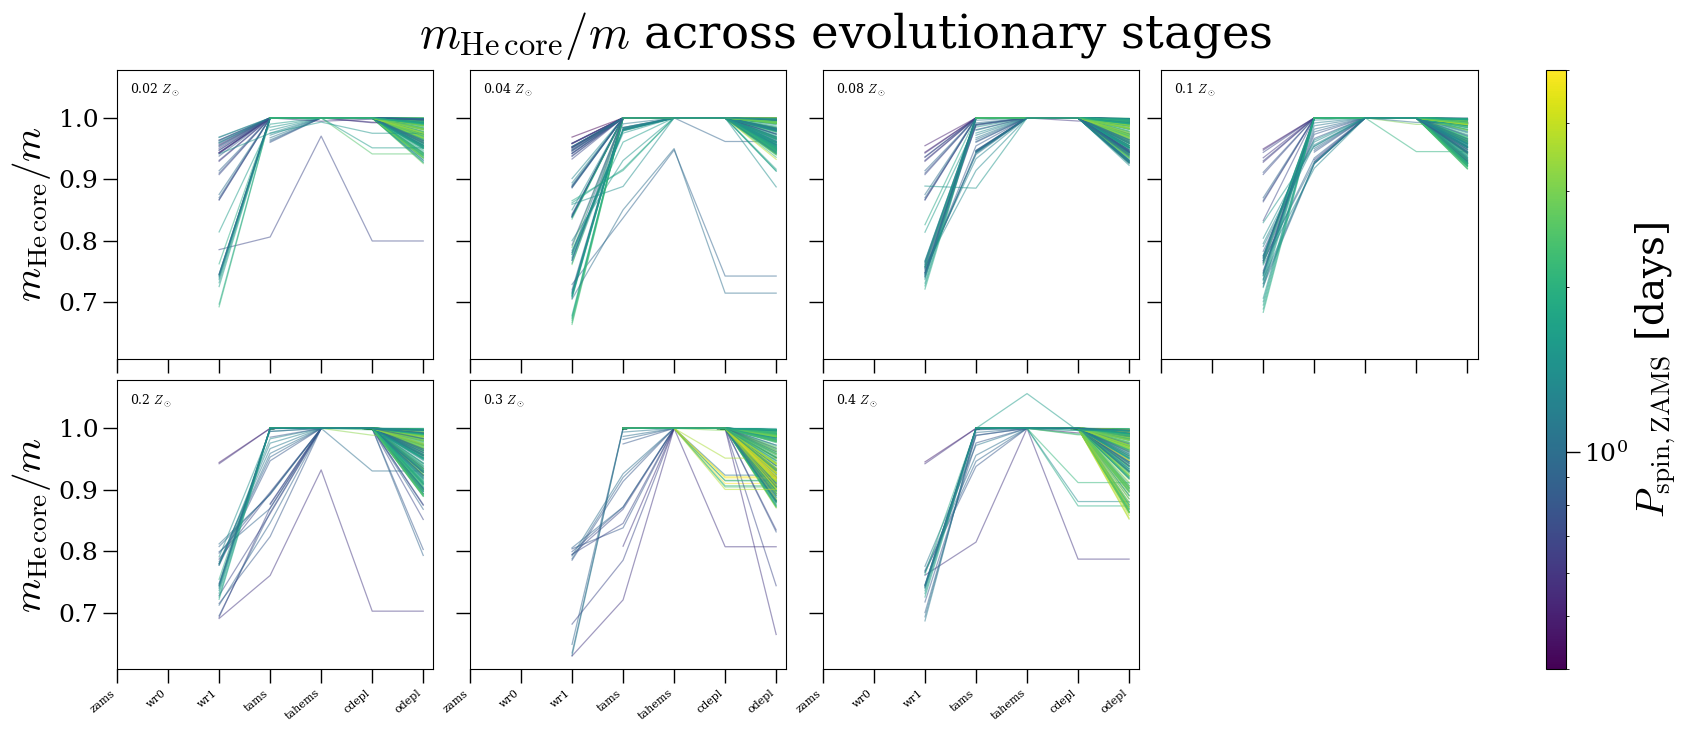

In [39]:
fig, axes = plot_core_ratio_tracks(work_df, core='he')

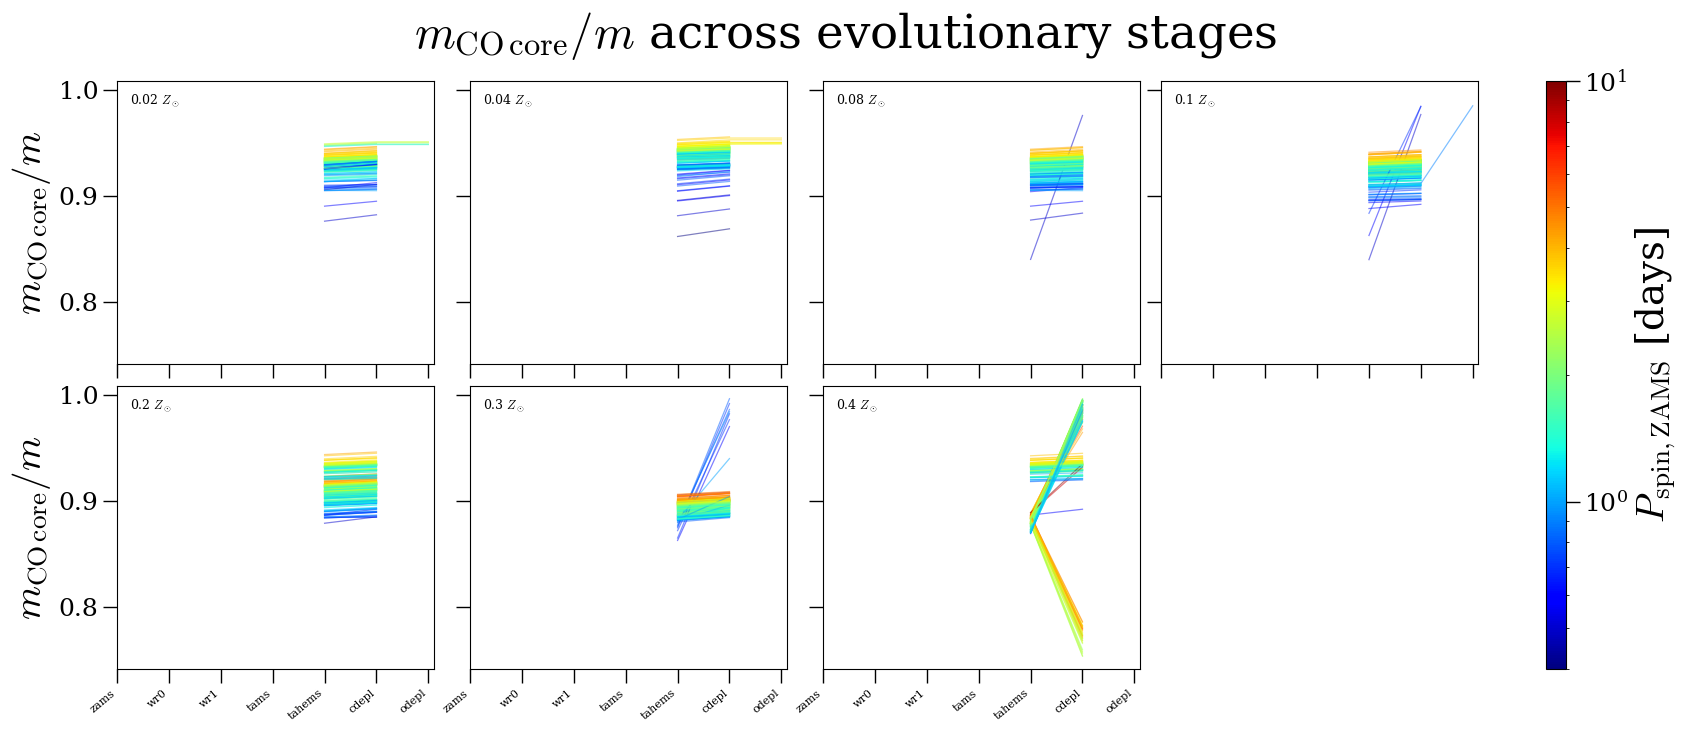

In [37]:
fig, axes = plot_core_ratio_tracks(work_df, core='co')